Original Dataset
   Company   Age  Salary     Place Country  Gender
0      TCS  20.0     NaN   Chennai   India       0
1  Infosys  30.0     NaN    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0

Shape:
(148, 6)

--- UNIQUE VALUES ---

 Company
['TCS' 'Infosys' 'CTS' 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 6

 Age
[20. 30. 35. 40. 23. 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41. 24.
 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29

 Salary
[2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030. 3045.
 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934. 4034.
 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787. 3454.
 5654. 5009. 5098. 3033.]
Length: 40

 Place
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 11

 Cou

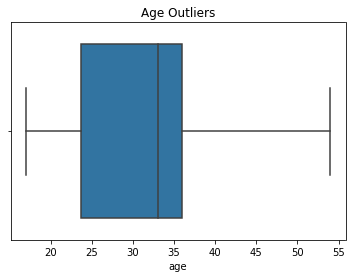

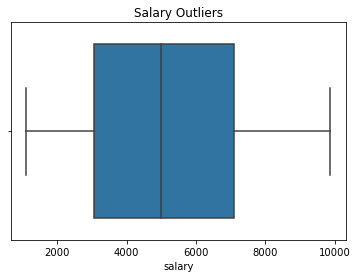


Filtered Data:
     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


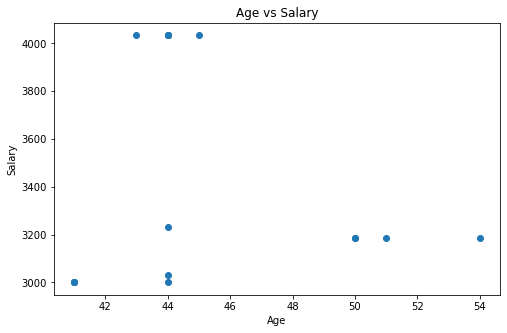


People from each place:
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: place, dtype: int64


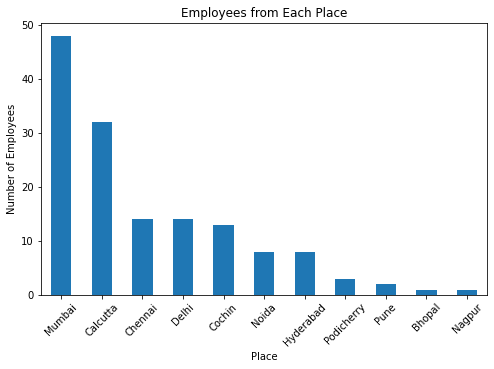


One-Hot Encoded Data:
    age  salary  gender  company_CTS  company_Congnizant  company_Infosys  \
0  20.0  5000.0       0            0                   0                0   
1  30.0  5000.0       0            0                   0                1   
2  35.0  2300.0       0            0                   0                0   
3  40.0  3000.0       0            0                   0                1   
4  23.0  4000.0       0            0                   0                0   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                        0            1                                  0   
1                        0            0                                  0   
2                        0            1                                  0   
3                        0            0                                  0   
4                        0            1                                  0   

   place_Bhopal  ...  place_Chennai  place_Co

In [7]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


#1. Data Exploration: 
        #● Explore the data, list down the unique values in each feature and find its length.
        #● Perform the statistical analysis and renaming of the columns.
df = pd.read_csv("Employee.csv")

print("Original Dataset")
print(df.head())

print("\nShape:")
print(df.shape)

print("\n--- UNIQUE VALUES ---")

for column in df.columns:
    print("\n", column)
    print(df[column].dropna().unique())
    print("Length:", df[column].dropna().nunique())


print("\n--- STATISTICAL ANALYSIS ---")
print(df.describe(include='all'))

df.rename(columns={
    'Company': 'company',
    'Age': 'age',
    'Salary': 'salary',
    'Place': 'place',
    'Country': 'country',
    'Gender': 'gender'
}, inplace=True)

print("\nRenamed Columns:")
print(df.columns)

#2. Data Cleaning: 
        #● Find the missing and inappropriate values, treat them appropriately.
        #● Remove all duplicate rows.
        #● Find the outliers.
        #● Replace the value 0 in age as NaN Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode) .

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

df['age'] = df['age'].replace(0, np.nan)

df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].median())

df['company'] = df['company'].fillna(df['company'].mode()[0])
df['place'] = df['place'].fillna(df['place'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0])


print("\nMissing values after treatment:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['age'])
plt.title("Age Outliers")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['salary'])
plt.title("Salary Outliers")
plt.show()


#3. Data Analysis: 
        #● Filter the data with age >40 and salary<5000 Plot the chart with age and salary Count the number of people from each place and represent it visually

filtered_df = df[
    (df['age'] > 40) &
    (df['salary'] < 5000)
]

print("\nFiltered Data:")
print(filtered_df)

plt.figure(figsize=(8, 5))

plt.scatter(
    filtered_df['age'],
    filtered_df['salary']
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()

place_count = df['place'].value_counts()

print("\nPeople from each place:")
print(place_count)

plt.figure(figsize=(8, 5))

place_count.plot(kind='bar')

plt.xlabel("Place")
plt.ylabel("Number of Employees")
plt.title("Employees from Each Place")

plt.xticks(rotation=45)

plt.show()


#4. Data Encoding: 
        #● Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.

one_hot_df = pd.get_dummies(
    df,
    columns=['company', 'place', 'country'],
    dtype=int
)

print("\nOne-Hot Encoded Data:")
print(one_hot_df.head())


label_encoder = LabelEncoder()

label_df = df.copy()

label_df['company_encoded'] = label_encoder.fit_transform(
    label_df['company']
)

label_df['place_encoded'] = label_encoder.fit_transform(
    label_df['place']
)

label_df['country_encoded'] = label_encoder.fit_transform(
    label_df['country']
)

print("\nLabel Encoded Data:")
print(label_df.head())


#5. Feature Scaling: (Score : 2)
        #● After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

standard_df = df.copy()

standard_scaler = StandardScaler()

standard_df[['age', 'salary']] = standard_scaler.fit_transform(
    standard_df[['age', 'salary']]
)

print("\nStandard Scaled Data:")
print(standard_df.head())

minmax_df = df.copy()

minmax_scaler = MinMaxScaler()

minmax_df[['age', 'salary']] = minmax_scaler.fit_transform(
    minmax_df[['age', 'salary']]
)

print("\nMinMax Scaled Data:")
print(minmax_df.head())